In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from helpers.helper_functions import *

# Handling text 2 exercise
[Handling text exercisses ADApted drom ADA 2018 final exam]


The Sheldon Cooper we all know and love (OK, some of us might not know him, and some might not love him) from the TV series "The Big Bang Theory" has gotten into an argument with Leonard from the same TV show. Sheldon insists that he knows the show better than anyone, and keeps making various claims about the show, which neither of them know how to prove or disprove. The two of them have reached out to you ladies and gentlemen, as data scientists, to help them. You will be given the full script of the series, with information on the episode, the scene, the person saying each dialogue line, and the dialogue lines themselves.

Leonard has challenged several of Sheldon's claims about the show, and throughout this exam you will see some of those and you will get to prove or disprove them, but remember: sometimes, we can neither prove a claim, nor disprove it!

## Task A: Picking up the shovel

**Note: You will use the data you preprocess in this task in all the subsequent ones.**

Our friends' argument concerns the entire show. We have given you a file in the `data/` folder that contains the script of every single episode. New episodes are indicated by '>>', new scenes by '>', and the rest of the lines are dialogue lines. Some lines are said by multiple people (for example, lines indicated by 'All' or 'Together'); **you must discard these lines**, for the sake of simplicity. However, you do not need to do it for Q1 in this task -- you'll take care of it when you solve Q2.

**Q1**. Your first task is to extract all lines of dialogue in each scene and episode, creating a dataframe where each row has the episode and scene where a dialogue line was said, the character who said it, and the line itself. You do not need to extract the proper name of the episode (e.g. episode 1 can appear as "Series 01 Episode 01 - Pilot Episode", and doesn't need to appear as "Pilot Episode"). Then, answer the following question: In total, how many scenes are there in each season? We're not asking about unique scenes; the same location appearing in two episodes counts as two scenes. You can use a Pandas dataframe with a season column and a scene count column as the response.

**Note: The data refers to seasons as "series".**

In [2]:
season = ""
episode = ""
scene = ""
data = []
with open("data/all_scripts.txt", "r", encoding="utf-8-sig") as f:
    for line in f.readlines():
        line = line[:-1] # removes the last character from the current string line (typically the trailing newline \n read from the file).
        if line.startswith(">> "):
            season = int(line[10:12]) # [10:12] It slices the string to take characters at positions 10 and 11
            episode = line[3:] # It slices the string from index 3 to the end, i.e., drops the leading ">> " from the episode header
            continue
        if line.startswith("> "):
            scene = line[2:]
            continue
        character, line = line.split(": ", 1) # It splits the dialogue line at the first occurrence of ": " into two parts: the speaker name (character) and the remainder of the dialogue text (line), using maxsplit=1 so only the first separator is used.
        data.append([season, episode, scene, character, line])
lines = pd.DataFrame(data, columns=["Season", "Episode", "Scene", "Character", "Line"])
display(lines.head())

,Season,Episode,Scene,Character,Line
0,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Sheldon,So if a photon is directed through a plane wit...
1,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Leonard,"Agreed, what’s your point?"
2,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Sheldon,"There’s no point, I just think it’s a good ide..."
3,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Leonard,Excuse me?
4,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Receptionist,Hang on.


In [3]:
(lines.groupby(["Season", "Episode", "Scene"])     # group rows by unique (Season, Episode, Scene)
     .count()                                      # count rows per group (any column works for the count)
     .reset_index()                                # turn group keys back into columns, which converts the current grouped index (Season, Episode, Scene) back into regular dataframe columns so they can be regrouped or counted again
     .groupby("Season")                            # regroup by Season
     .count()[["Scene"]]                           # count how many scene rows per season; keep the Scene count column
)
# lines.groupby(["Season", "Episode", "Scene"]).count().reset_index().groupby("Season").count()[["Scene"]]

,Scene
Season,
1,157
2,205
3,193
4,219
5,198
6,211
7,207
8,191
9,177


**Q2**. Now, let's define two sets of characters: all the characters, and recurrent characters. Recurrent characters are those who appear in more than one episode. For the subsequent sections, you will need to have a list of recurrent characters. Assume that there are no two _named characters_ (i.e. characters who have actual names and aren't referred to generically as "little girl", "grumpy grandpa", etc.) with the same name, i.e. there are no two Sheldons, etc. Generate a list of recurrent characters who have more than 90 dialogue lines in total, and then take a look at the list you have. If you've done this correctly, you should have a list of 20 names. However, one of these is clearly not a recurrent character. Manually remove that one, and print out your list of recurrent characters. To remove that character, pay attention to the _named character_ assumption we gave you earlier on. **For all the subsequent questions, you must only keep the dialogue lines said by the recurrent characters in your list.**

In [4]:
lines_per_chars = lines.groupby("Character").count()[["Line"]]
recurrent_chars = lines_per_chars[lines_per_chars["Line"] > 90]
recurrent_chars

,Line
Character,
Amy,3472
Arthur,130
Bernadette,2690
Bert,95
Beverley,162
Emily,164
Howard,5872
Kripke,106
Leonard,9829


In [5]:
recurrent_chars = recurrent_chars.drop("Man", axis=0)
recurrent_chars

,Line
Character,
Amy,3472
Arthur,130
Bernadette,2690
Bert,95
Beverley,162
Emily,164
Howard,5872
Kripke,106
Leonard,9829


## Task B: Read the scripts carefully

### Part 1: Don't put the shovel down just yet

**Q3**. From each dialogue line, replace punctuation marks (listed in the EXCLUDE_CHARS variable provided in `helpers/helper_functions.py`) with whitespaces, and lowercase all the text. **Do not remove any stopwords, leave them be for all the questions in this task.**

In [6]:
def clean_line(line):
    for char in EXCLUDE_CHARS:
        line = line.replace(char, ' ')
    return line.lower()
lines["Line"] = lines["Line"].apply(clean_line)
lines.head()

,Season,Episode,Scene,Character,Line
0,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Sheldon,so if a photon is directed through a plane wit...
1,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Leonard,agreed what s your point
2,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Sheldon,there s no point i just think it s a good ide...
3,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Leonard,excuse me
4,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Receptionist,hang on


**Q4**. For each term, calculate its "corpus frequency", i.e. its number of occurrences in the entire series. Visualize the distribution of corpus frequency using a histogram. Explain your observations. What are the appropriate x and y scales for this plot?

In [7]:
# Concatenate all words from all dialogue lines into a single Series:
# - lines.iterrows() iterates over each row
# - row['Line'].split(' ') splits each dialogue line into individual words
# - pd.Series(...) converts each word list into a Series
# - pd.concat([...]) concatenates all Series into one (all words from corpus)
# - reset_index() creates a DataFrame with index and word columns
corpus_frequency = pd.concat([pd.Series(row['Line'].split(' ')) for _, row in lines.iterrows()]).reset_index()
# modified the following code to make everything work
corpus_frequency.columns = ["index", "Word"] # It renames the two columns of the corpus_frequency DataFrame to "index" and "Word" (after reset_index(), the default column names would be "index" and 0).
corpus_frequency = corpus_frequency.groupby("Word").count()[["index"]] # It groups the DataFrame by "Word", counts how many times each word appears (the count shows up in the "index" column), and keeps only that "index" column—giving the frequency count for each unique word.
corpus_frequency.columns = ["Frequency"] # It renames the column from "index" to "Frequency" to make it more descriptive—the column now clearly represents word frequency counts.
print(corpus_frequency)
#code de base
# corpus_frequency.columns = ["Frequency", "Word"]
# corpus_frequency = corpus_frequency.groupby("Word").count()

       Frequency
Word            
          136530
0              6
00             5
000           33
000lb          1
...          ...
…tion          1
…when          1
…who           1
‭yeah          1
♪              1

[21692 rows x 1 columns]


**(moi) Note:** After `groupby("Word")`, `"Word"` becomes the **index** (not a regular column), so the DataFrame structure is:
- **Index:** Word 
- **Column:** Frequency (renamed from "index")

When you print it, Word appears first because it's the index. If you want both as regular columns, add `reset_index()` after the groupby:

```python
corpus_frequency = corpus_frequency.groupby("Word").count()[["index"]].reset_index()
```

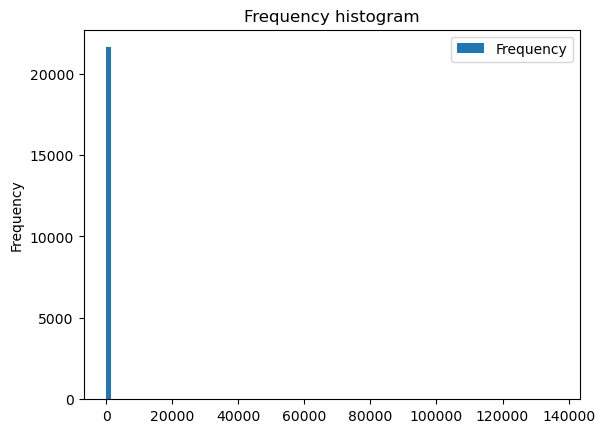

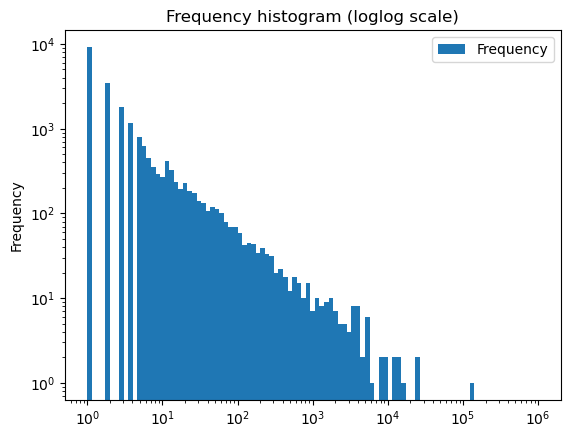

In [8]:
corpus_frequency.plot.hist(column=["Frequency"], bins=100, title="Frequency histogram")
corpus_frequency.plot.hist(column=["Frequency"], loglog=True, bins=np.logspace(0, 6, 100), #bins=np.logspace(0, 6, 100) : creates 100 bins spaced evenly on a logarithmic scale from 10^0 (1) to 10^6 (1,000,000).
                           title="Frequency histogram (loglog scale)");

**(moi) Histogram Axes Explanation:**

- **X-axis (Frequency):** The number of times a word appears in the entire corpus (dialogue from all episodes). Ranges from 1 to several thousand.
- **Y-axis (Count):** The number of distinct words that have that frequency. Higher bars mean more words share the same frequency.

**Example with bins=100:** 
The histogram divides the frequency range into 100 bins. If one bin covers frequencies 10-20:
- That bin's bar height shows how many words appear between 10 and 20 times in the corpus
- For instance, if the bar height is 500, it means there are 500 unique words that appear 10-20 times

The **loglog scale** (second plot) makes the power-law distribution visible: most words appear rarely while a few words appear very frequently.


The distribution of frequencies follows a power law. The correct way to visualize this frequency is on a log-log scale.

### Part 2: Talkativity
**Q5**. For each of the recurrent characters, calculate their total number of words uttered (prononcé) across all episodes. Based on this, who seems to be the most talkative character?

In [17]:
# Create a new column "Words" that counts the number of words in each dialogue line
# - lambda x: len(x.split()) splits each line by spaces and counts the resulting words
lines["Words"] = lines["Line"].apply(lambda x: len(x.split()))

# Group by Character and sum the total word count for each character
# - .groupby("Character") groups all rows by character name
# - .sum()["Words"] sums up the word counts for each character
words_per_char = lines.groupby("Character").sum()["Words"]
# Filter to show only the recurrent characters (using the index from recurrent_chars DataFrame)
words_per_char[recurrent_chars.index]

Character
Amy              39933
Arthur            1451
Bernadette       27726
Bert              1146
Beverley          2029
Emily             1571
Howard           69505
Kripke            1246
Leonard         102496
Leslie            1249
Mrs Cooper        3389
Mrs Wolowitz      1459
Penny            79270
Priya             1940
Raj              60099
Sheldon         185388
Stuart            7955
Wil               1678
Zack              1427
Name: Words, dtype: int64

In [10]:
print("Most talkative character: ", words_per_char[recurrent_chars.index].idxmax()) # .idxmax() returns the index (character name) of the maximum value in the Series

Most talkative character:  Sheldon


## Task D: The Detective's Hat

Sheldon claims that given a dialogue line, he can, with an accuracy of above 70%, say whether it's by himself or by someone else. Leonard contests this claim, since he believes that this claimed accuracy is too high.

**Q6**. Divide the set of all dialogue lines into two subsets: the training set, consisting of all the seasons except the last two, and the test set, consisting of the last two seasons.

In [11]:
train_set = lines[lines["Season"] <= lines["Season"].max() - 2]
train_set.head()

,Season,Episode,Scene,Character,Line,Words
0,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Sheldon,so if a photon is directed through a plane wit...,57
1,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Leonard,agreed what s your point,5
2,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Sheldon,there s no point i just think it s a good ide...,16
3,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Leonard,excuse me,2
4,1,Series 01 Episode 01 – Pilot Episode,A corridor at a sperm bank.,Receptionist,hang on,2


In [12]:
test_set = lines[lines["Season"] > lines["Season"].max() - 2]
test_set.head()

,Season,Episode,Scene,Character,Line,Words
40354,9,Series 09 Episode 01 – The Matrimonial Momentum,A Wedding Chapel.,Penny,so what package are you thinking,6
40355,9,Series 09 Episode 01 – The Matrimonial Momentum,A Wedding Chapel.,Leonard,mm this one comes with music and flowers oh ...,19
40356,9,Series 09 Episode 01 – The Matrimonial Momentum,A Wedding Chapel.,Penny,why would we want that,5
40357,9,Series 09 Episode 01 – The Matrimonial Momentum,A Wedding Chapel.,Leonard,‘cause there s a lot of gorgeous blondes out t...,26
40358,9,Series 09 Episode 01 – The Matrimonial Momentum,A Wedding Chapel.,Penny,whatever put us on the internet i ve always ...,16


**Q7**. Find the set of all words in the training set that are only uttered by Sheldon. Is it possible for Sheldon to identify himself only based on these? Use the test set to assess this possibility, and explain your method.

In [ ]:
# Step 1: Create a mapping of each word to the character who said it
# For each row in train_set:
#   - row['Line'].split() breaks the dialogue into individual words
#   - pd.Series(row["Character"], row['Line'].split()) creates a Series where:
#       * the index is each word from the line
#       * the value is the character name (repeated for all words)
# pd.concat combines all these Series into one, then reset_index() makes the words a column
words_for_chars = pd.concat([pd.Series(row["Character"], row['Line'].split())
                             for _, row in train_set.iterrows()]).reset_index()
# Rename columns: "index" contains the words, and the value column contains character names
words_for_chars.columns = ["Word", "Character"]

# Step 2: Group by word and create a set of all characters who said that word
# This transforms the data so each word maps to a set of character names
# Example: "bazinga" -> {"Sheldon"}, "yeah" -> {"Sheldon", "Leonard", "Penny", ...}
words_for_chars = words_for_chars.groupby("Word")["Character"].apply(set) # It groups the DataFrame by "Word" and applies the set function to the "Character" column, resulting in each word being associated with a set of unique characters who have spoken that word. 

# Step 3: Filter to find words spoken ONLY by Sheldon
# Keep only words where:
#   - "Sheldon" is in the set of characters who said it, AND
#   - The set has exactly 1 character (meaning only Sheldon said it)
# .index gives us the actual word strings (since words are the index after groupby)
sheldon_words = words_for_chars[words_for_chars.apply(lambda x: ("Sheldon" in x) and (len(x) == 1))].index

In [ ]:
def contains_sheldon_words(line):
    for word in sheldon_words:
        if word in line.split():
            return True
    return False
test_pred = test_set["Line"].apply(contains_sheldon_words) #is a boolean Series (same length as test_set) giving the model’s prediction per dialogue line: it’s True when the line contains at least one word from sheldon_words (words spoken only by Sheldon in training), and False otherwise.
test_true = test_set["Character"] == "Sheldon" # is a pandas Series of booleans the same length as test_set, where each entry is True if the corresponding dialogue line in test_set["Character"] equals "Sheldon" and False otherwise.

In [15]:
print("Accuracy: ", (test_true == test_pred).sum() / len(test_true))

Accuracy:  0.7825013713658804


We know that a line that contains a word that is only said by Sheldon has to be said by Sheldon. Our simple classifier classifies such lines as uttered by Sheldon, and other lines as not uttered by Sheldon. This results in an accuracy of 78% on the test set.

To build our classifier, we need to isolate the words that are only said by Sheldon, (`sheldon_words`), by first associating each word in the line to the character that uttered the line, then grouping by words and keeping only the ones that contain only "Sheldon" as `Character`.

# (moi) Summary
- Parsed scripts into season/episode/scene/character/line records and counted scenes per season.
- Identified recurrent characters (>90 lines) and cleaned punctuation/lowercased dialogue for analysis.
- Computed corpus word frequencies, visualized histograms (linear and log-log), and noted power-law behavior.
- Tallied words per recurrent character to find the most talkative.
- Split data into train (all but last two seasons) and test (last two) sets.
- Built a simple Sheldon-only-word classifier and measured accuracy (~78%) on the test set.